# Enviroment and Dependencies setup

## Install Essential Dependencies

In [1]:
!pip install ml-collections

## Folder Structure setup

In [2]:
on_colab = False

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    on_colab = True
except Exception as e:
    on_colab = False

 PLEASE CHANGE THE DIRECTORY PATH ON THE BELOW CELL CORRESPONDING TO THE FOLDER CONTAIN THIS NOTEBOOK

In [3]:
#%cd "/content/drive/MyDrive/FYP/TCT code/TCT-visual-search/TCT notebooks"

## Google Colab directory setup

In [4]:
import os
import shutil

if on_colab:

    print('Notebook on Google Colab, copying files to separate directory from personal drive...')

    # _____ COPY DATASET ZIP FILE _____


    os.makedirs('/src/TCT-visual-search/datasets/coco-search18/', exist_ok=True)

    shutil.copyfile('../datasets/coco-search18/coco-search18_dataset.zip', '/src/TCT-visual-search/datasets/coco-search18/coco-search18_dataset.zip')

    print('Done copying dataset zip file!')
    # _____ COPY DATASET ZIP FILE _____



    # _____ COCO-SEARCH18 UTILS FILE _____
    shutil.copyfile('../datasets/coco-search18/image_info.pkl', '/src/TCT-visual-search/datasets/coco-search18/image_info.pkl')
    shutil.copyfile('../datasets/coco-search18/random_filenames_pairs_0915.pkl', '/src/TCT-visual-search/datasets/coco-search18/random_filenames_pairs_0915.pkl')
    print('Done copying coco-search18 utils files')
    # _____ COCO-SEARCH18 UTILS FILE _____



    # _____ COPY CRT ATTENTION MAP _____
    # os.makedirs('/src/vit-visual-search/context/', exist_ok=True)
    # shutil.copyfile('../context/CRT_coco18test_modelmix4ZR_original_1008.pkl', '/src/vit-visual-search/context/CRT_coco18test_modelmix4ZR_original_1008.pkl')
    # shutil.copyfile('../context/CRT_naturaldesign_modelmix4ZR_original_1008.pkl', '/src/vit-visual-search/context/CRT_naturaldesign_modelmix4ZR_original_1008.pkl')
    # shutil.copyfile('../context/CRT_SCEGRAM_modelmix4ZR_original_1008.pkl', '/src/vit-visual-search/context/CRT_SCEGRAM_modelmix4ZR_original_1008.pkl')
    # print('Done copying CRT attention map files')
    # _____ COPY CRT ATTENTION MAP _____


    # ____ COPY MODEL WEIGHTS _____
    shutil.copyfile('../ViT_utils/vitpytorch_cifar100_finetune_no_posembed.pt', '/src/vit-visual-search/vitpytorch_cifar100_finetune_no_posembed.pt')
    print('Done copying model weights')
    # ____ COPY MODEL WEIGHTS _____
    
    root_folder = '/src'

## Local Machine directory setup

In [5]:
import os

if not on_colab:
    
    
    root_folder = '../..'


## User-defined environment variables

In [6]:
store_attn_on_local: bool = False
store_rel_on_local:  bool = True

In [7]:
if store_attn_on_local or store_rel_on_local:
    if on_colab:
        if os.path.exists('/src/TCT-visual-search/results'):
            os.unlink('/src/TCT-visual-search/results')
        os.symlink(os.path.abspath('../results'), '/src/vit-visual-search/results')

## Environment variables setup

In [8]:
# _________ APPEND SOME PATH TO IMPORT SOME LIBRARY BELOW _____________
import sys

sys.path.append('..')
sys.path.append('../ViT_utils')
# sys.path.append('../..')
# sys.path.append('../../irl_dcb')
# sys.path.append('../../irl_dcb/irl_dcb')

# _________ APPEND SOME PATH TO IMPORT SOME LIBRARY BELOW _____________

## Unzipping datasets files

In [9]:
import zipfile
import shutil


# Specify the path to your zip file
zip_file_path = os.path.join(
    root_folder, 
    'TCT-visual-search/datasets/coco-search18/coco-search18_dataset.zip'
)


# Specify the destination directory where you want to extract the contents
# If not provided, it extracts to the current working directory.
destination_directory = os.path.join(
    root_folder,
    'TCT-visual-search/datasets/coco-search18/'
)


# Create the destination directory if it doesn't exist
if not os.path.exists(destination_directory):
    os.makedirs(destination_directory)

if not os.path.exists(os.path.join(destination_directory, 'coco-search18_dataset')):
    print('Unzip file not found start unzipping!')

    try:
        # Open the zip file in read mode ('r')
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            # Extract all the contents to the specified destination directory
            zip_ref.extractall(destination_directory)
        print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is not a valid ZIP file.")
    except FileNotFoundError:
        print(f"Error: ZIP file '{zip_file_path}' not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
else:
    print('Unzip dataset file found!')

if not os.path.exists(os.path.join(destination_directory, 'coco-search18_dataset', 'image_info.pkl')):
    source_file = os.path.join(destination_directory, 'image_info.pkl')
    destination_file = os.path.join(destination_directory, 'coco-search18_dataset', 'image_info.pkl')

    shutil.copyfile(source_file, destination_file)
    print(f"File '{source_file}' copied to '{destination_file}' (contents only).")

if not os.path.exists(os.path.join(destination_directory, 'coco-search18_dataset', 'random_filenames_pairs_0915.pkl')):
    source_file = os.path.join(destination_directory, 'random_filenames_pairs_0915.pkl')
    destination_file = os.path.join(destination_directory, 'coco-search18_dataset', 'random_filenames_pairs_0915.pkl')

    shutil.copyfile(source_file, destination_file)
    print(f"File '{source_file}' copied to '{destination_file}' (contents only).")

Unzip dataset file found!


## Importing and defining essential dependencies

## Importing essential libraries

In [10]:
import json
import numpy as np
import torch
from os.path import join
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns
from itertools import product
from PIL import Image
# import cv2
from tqdm import tqdm
import pickle
from torch.utils.data import Dataset, DataLoader
from glob import glob


# import dataset
from tasks.visual_search2 import *

from visual_search_utils.utils import *

# from irl_dcb.utils import *
from torchvision import transforms
from visual_search_utils.data.coco18 import coco18

import copy



import yaml

from CRT_utils.CRT.core.model import Model

from ml_collections import ConfigDict

### Defining dataset class for CRT attention

In [11]:
import sys
import cv2
import time
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import numpy as np
import pandas as pd
import pickle
import random
import copy

from PIL import Image, ImageDraw

import torch
from torch.utils.data import Dataset
from torchvision.transforms.functional import to_tensor, normalize
from torchvision import transforms

target_min = 128
patch_w = 16

class coco18_crt(Dataset):
    def __init__(self, dataset_dir, task, search_size, target_size, resize_transform_size=(320, 512), per_target=True, is_transform=True):
        self.dataset_dir = dataset_dir
        self.task        = task
        self.search_dir  = os.path.join(self.dataset_dir, "images", self.task)

        with open(os.path.join(self.dataset_dir, "image_info.pkl"), 'rb') as handle:
            self.image_info = pickle.load(handle)

        with open(os.path.join(self.dataset_dir, "random_filenames_pairs_0915.pkl"), 'rb') as handle:
            self.search_target_pair = pickle.load(handle)

        self.bbox_info    = np.load(os.path.join(self.dataset_dir, "processed/bbox_annos.npy"), allow_pickle=True).item()
        self.search_size  = search_size
        self.target_size  = target_size if not per_target else None
        self.per_target   = per_target
        self.is_transform = is_transform

        self.resize_transform_size = resize_transform_size

        self.search_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(search_size),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.target_transform = transforms.Compose([
            transforms.Resize(target_size),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ]) if not per_target else None

        self.resize_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(resize_transform_size),
        ])

    def __len__(self):
        return len(self.image_info[self.task]['names'])

    def __getitem__(self, idx):
        search_name = self.image_info[self.task]['names'][idx]
        search_key  = self.task + '_' + search_name
        target_name = self.search_target_pair[search_key].split('_')[-1]
        target_key  = self.task + '_' + target_name
        search_file = os.path.join(self.search_dir, search_name)
        target_file = os.path.join(self.search_dir, target_name)

        # calculate the bounding box cordinates and the solution image
        bbox = self.bbox_info[search_key]

        resize_img_w = self.resize_transform_size[1]
        resize_img_h = self.resize_transform_size[0]

        img_w = self.search_size[1]
        img_h = self.search_size[0]

        bbox_relative = torch.tensor(
            [
                bbox[0] / resize_img_w * img_w,
                bbox[1] / resize_img_h * img_h,
                bbox[2] / resize_img_w * img_w,
                bbox[3] / resize_img_h * img_h
            ], dtype=torch.int)

        solution = np.zeros(self.search_size)
        solution[bbox_relative[1]:bbox_relative[1]+bbox_relative[3], bbox_relative[0]:bbox_relative[0]+bbox_relative[2]] = 1

        # process search img
        img = Image.open(search_file).convert('RGB')
        target = Image.open(target_file).convert('RGB')


        t_bbox = self.bbox_info[target_key]


        if self.is_transform:
            # transform search image
            img = self.search_transform(img)
            target = self.resize_transform(target)




            target = target[:, t_bbox[1]:t_bbox[1]+t_bbox[3], t_bbox[0]:t_bbox[0]+t_bbox[2]]

            # transform target image
            if not self.per_target:
                target = self.target_transform(target)
            else:
                target_w, target_h = target.shape[2], target.shape[1]


                target_max = int((target_min * max(target_w, target_h) / min(target_w, target_h)) // patch_w * patch_w)


                if target_w >= target_h:
                    target_w, target_h = target_max, target_min
                else:
                    target_h, target_w = target_max, target_min

                target_transform = transforms.Compose([
                                  transforms.Resize((target_h, target_w)),
                                  transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
                ])
                target = target_transform(target)

        bbox_relative = torch.tensor(
            [
                bbox[0] / resize_img_w,
                bbox[1] / resize_img_h,
                bbox[2] / resize_img_w,
                bbox[3] / resize_img_h
            ], dtype=torch.float
        )

        return img, target, solution, bbox_relative

### Defining utils functions

In [12]:
def get_CRT_attn(
        CRT_model      : torch.nn.Module,
        search_img     : torch.tensor,
        target_img     : torch.tensor,
#         relative_bbox  : torch.tensor,
        # final_attn_size: tuple[int, int],
        attn_head_idx  : int = 4,
        device         : str = 'cpu'
) -> torch.tensor:

    search_img    = search_img.to(device)
    target_img    = target_img.to(device)
#     relative_bbox = relative_bbox.to(device)

    CRT_model.eval()
    with torch.no_grad():
        # _____ PREVIOUS VERSION _____
#         _, attention_CRTNet = CRT_model(search_img.unsqueeze(0), target_img.unsqueeze(0), relative_bbox.unsqueeze(0))

        # _____ PREVIOUS VERSION _____
        
        
        # _____ MODIFIED VERSION _____
        _, attention_CRTNet = CRT_model(
            search_img.unsqueeze(0), 
            target_img.unsqueeze(0)
        )
        # _____ MODIFIED VERSION _____
        
        
        
    attention_CRTNet = attention_CRTNet.detach().squeeze()

    attention_w = attention_h = int(np.sqrt(attention_CRTNet.shape[1]))

    attention_CRTNet = attention_CRTNet.reshape(attention_CRTNet.size(0), 7, 7)
    
#     num_attn_head = attention_CRTNet.shape[0]
    
#     final_attention = torch.tensor(np.zeros(attention_CRTNet[0].shape), dtype=torch.float).to(device)
    
#     for head_idx in range(num_attn_head):
#         final_attention += attention_CRTNet[head_idx]
        
#     final_attention /= num_attn_head
    
    # _____ PREVIOUS VERSION _____
    attention_CRTNet = copy.deepcopy(attention_CRTNet[attn_head_idx].unsqueeze(0))
    # _____ PREVIOUS VERSION _____
    

    # _____ MODIFIED VERSION _____
    
#     attention_CRTNet = copy.deepcopy(final_attention.unsqueeze(0))
    # _____ MODIFIED VERSION _____
    
    
    
    # attention_CRTNet =  transforms.Resize((final_attn_size[0], final_attn_size[1]))(attention_CRTNet.unsqueeze(0))

    return attention_CRTNet

### User-defined code variables

In [13]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps"  # macbook uses metal performance shaders to GPU accelearation
    if torch.backends.mps.is_available()
    else "cpu"
)

search_w_crt = 224
search_h_crt = 224

search_w     = 512
search_h     = 320
target_min   = 128
patch_w      = 16
patch_h      = 16

n_patch_w, n_patch_h = int(search_w // patch_w), int(search_h // patch_h)

IOR_size     = 24
dataset      = 'coco18'
n_random     = 100



if dataset == 'coco18':
    # test_traj = json.load(open('/src/coco-search18_dataset/processed/coco_search18_fixations_TP_test.json'))
    test_traj = json.load(
        open(
            os.path.join(
                root_folder,
                'TCT-visual-search/datasets/coco-search18/coco-search18_dataset/processed/human_scanpaths_TP_trainval_valid.json'
            )
            
        )
    )
    tasks     = np.unique(pd.DataFrame(test_traj)['task'].values)


dataset_dir = os.path.join(destination_directory, 'coco-search18_dataset')

### Loading weights for CRT and ViT model

#### CRT model

In [14]:
checkpoint = "../CRT_utils/CRT_weights_and_config/CRT_COCO_all_attention/checkpoint_30.tar"
config     = "../CRT_utils/CRT_weights_and_config/CRT_COCO_all_attention/config.yaml"

with open(config) as f:
    cfg = ConfigDict(yaml.load(f, Loader=yaml.Loader))

if not hasattr(cfg, "num_classes"):     # infer number of classes
    with open(cfg.annotations, 'rb') as f:
        NUM_CLASSES = len(json.load(f)["categories"])
    cfg.num_classes = NUM_CLASSES

checkpoint = torch.load(checkpoint, map_location="cpu")

cfg.num_classes = 18                    # Pretrained model configuration

In [15]:
crt_model = Model.from_config(cfg)

In [16]:
crt_model.load_state_dict(checkpoint['model_state_dict'])
crt_model.extended_output = True
crt_model.training        = False

#### ViT model

In [17]:
# vit = load_model(device=device)

### Move both model to DEVICE

In [18]:
%%capture
crt_model.to(device)
# vit.to(device)

### Set both model to EVAL

In [19]:
%%capture
crt_model.eval()
# vit.eval()

# CRT Attention generation

In [20]:


crt_attn = {}

for i, task in enumerate(tqdm(tasks)):

    dset_config = dict(
        dataset_dir  = dataset_dir,
        task         = task,
        search_size  = (search_h_crt, search_w_crt),
        target_size  = (search_h_crt, search_w_crt),
        per_target   = False,
        is_transform = True
    )

    dset = coco18_crt(**dset_config)

    for i in range(len(dset)):

        name = dset.image_info[dset.task]['names'][i]
        key  = task + '_' + name

        s_im, t_im, solution, t_bbox = dset[i]

        crt_attn[key] = get_CRT_attn(
            CRT_model       = crt_model,
            search_img      = s_im,
            target_img      = t_im,
#             relative_bbox   = t_bbox,
            # final_attn_size = (7, 7),
            attn_head_idx   = 5,
            device          = device
        )



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:51<00:00,  2.87s/it]


# TCT Model

In [21]:
task_result = {}

for i, task in enumerate(tqdm(tasks)):
    result = dict()



    dset_config = dict(dataset_dir = dataset_dir, task=task, search_size=(search_h, search_w), target_size=(0, 0), per_target=True, is_transform=True)
    dset        = coco18(**dset_config)

    for i in tqdm(range(len(dset))):
        name = dset.image_info[dset.task]['names'][i]
        key  = task + '_' + name

        # if key not in crt_attn.keys():
        #     continue

        result[key] = dict()
        temp        = result[key]

        s_im, t_im, solution, t_bbox = dset.__getitem__(i)

        # Task 0: random search
        rands = []
        for n in range(n_random):
            np.random.seed(int(i + 1e3 + n))

            rand_attn     = np.random.rand(search_h, search_w)
            attn          = add_init_fix(rand_attn, search_w, search_h)
            rand_path_rel = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')

            rands.append(rand_path_rel)

        temp['rand_path_rel'] = rands

        # Task 1: CRT alone
        crt_tensor         = crt_attn[key]
        norm_crt_tensor    = crt_tensor / crt_tensor.max()
#         norm_crt_tensor = (crt_tensor - crt_tensor.min()) / (crt_tensor.max() - crt_tensor.min()) # normalize
        norm_crt_relevance = transforms.Resize((search_h, search_w))(norm_crt_tensor).cpu().squeeze().numpy()
        attn               = add_init_fix(norm_crt_relevance, search_w, search_h)
        crt_path_rel       = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')

        temp['crt_alone_path_rel'] = crt_path_rel

        # # normalized CRT relevance tensor
        # crt_tensor = transforms.Resize((n_patch_h, n_patch_w))(norm_crt_tensor).squeeze().reshape(-1).to(device)
        # crt_tensor = (crt_tensor - crt_tensor.mean()) / crt_tensor.std() * 100
        # crt_tensor = torch.sigmoid(crt_tensor)

        # # global context modulation alone, no target modulation
        # crt_mod_method        = 5
        # layer                 = 2
        # crt_global_mod_layers = [layer]
        # crt_global_mod        = crt_tensor
        # crt_local_mod         = None

        # mod_attn = get_attn(
        #     vit,
        #     s_im,
        #     crt_mod_method        = crt_mod_method,
        #     crt_global_mod_layers = crt_global_mod_layers,
        #     crt_global_mod        = crt_global_mod,
        #     crt_local_mod         = crt_local_mod,
        #     processed             = True,
        #     device                = device
        # )

        # attn                           = add_init_fix(mod_attn, search_w, search_h)
        # mod_path_rel                   = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
        # temp['crt_mod_alone_attn']     = mod_attn
        # temp['crt_mod_alone_path_rel'] = mod_path_rel

        # for crt in ['global_3']:
        # for crt in [None]:
        # for crt in [None, 'global_3']:
        #     # Task 2: VIT local modulation alone

        #     if crt is None:
        #         flag                  = ''
        #         crt_mod_method        = None
        #         crt_global_mod_layers = []
        #         crt_global_mod        = None
        #         crt_local_mod         = None

        #     # Task 3: Integrated CRT global & VIT local
        #     elif 'global' in crt:
        #         flag = 'crt_{}_'.format(crt)
        #         crt_mod_method        = 5
        #         layer                 = eval(crt.split('_')[1])-1
        #         crt_global_mod_layers = [layer]
        #         crt_global_mod        = crt_tensor
        #         crt_local_mod         = None

        #     attns, paths, product_attns, product_paths, sum_attns, sum_paths = [], [], [], [], [], []


        #     # for n in range(1, 13):
        #     for n in [7]:



        #         target_embedding = None
        #         mod_attn         = get_attn(
        #             vit,
        #             s_im,
        #             crt_mod_method        = crt_mod_method,
        #             crt_global_mod_layers = crt_global_mod_layers,
        #             crt_global_mod        = crt_global_mod,
        #             crt_local_mod         = crt_local_mod,
        #             mod_last_n            = n,
        #             t_im                  = t_im,
        #             target_embedding      = target_embedding,
        #             mod                   = 'relevance',
        #             processed             = True,
        #             device                = device
        #         )

        #         attn = add_init_fix(mod_attn, search_w, search_h)
        #         path = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
        #         attns.append(mod_attn)
        #         paths.append(path)

        #         if crt is None:
        #             # Task 5: product of crt clone and vit alone
        #             product_attn = mod_attn * norm_crt_relevance
        #             attn         = add_init_fix(product_attn, search_w, search_h)
        #             path         = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')

        #             product_attns.append(product_attn)
        #             product_paths.append(path)

        #             # Task 6:sum of crt clone and vit alone
        #             norm_mod_attn = (mod_attn - mod_attn.min()) / (mod_attn.max() - mod_attn.min())
        #             sum_attn      = norm_mod_attn + norm_crt_relevance
        #             attn          = add_init_fix(sum_attn, search_w, search_h)
        #             path          = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')

        #             sum_attns.append(sum_attn)
        #             sum_paths.append(path)

        #     temp['{}mod_attns'.format(flag)] = np.stack(attns)
        #     temp['{}paths_rel'.format(flag)] = paths

        #     if crt is None:
        #         temp['product_mod_attns'.format(flag)] = np.stack(product_attns)
        #         temp['product_paths_rel'.format(flag)] = product_paths
        #         temp['sum_mod_attns'.format(flag)] = np.stack(sum_attns)
        #         temp['sum_paths_rel'.format(flag)] = sum_paths

        #         # Task 4: unmodulated VIT
        #         unmod_attn = get_attn(
        #             vit,
        #             s_im,
        #             crt_mod_method        = crt_mod_method,
        #             crt_global_mod_layers = crt_global_mod_layers,
        #             crt_global_mod        = crt_global_mod,
        #             crt_local_mod         = crt_local_mod,
        #             processed             = True,
        #             device                = device
        #         )

        #         attn                   = add_init_fix(unmod_attn, search_w, search_h)
        #         unmod_path_rel         = search_task(attn, solution, inh_size=IOR_size, fix_method='relaxed')
        #         temp['unmod_attn']     = unmod_attn
        #         temp['unmod_path_rel'] = unmod_path_rel

    result_keys = result.keys()

    # if store_attn_on_local or store_rel_on_local:

    #     save_result = dict()

    #     for key in result_keys:
    #         save_result[key] = dict()

    #         result_key_keys  = result[key].keys()

    #         for key_key in result_key_keys:
    #             if ('attn' in key_key) and store_attn_on_local:
    #                 save_result[key][key_key] = copy.deepcopy(result[key][key_key])
    #             elif ('path' in key_key) and store_rel_on_local:
    #                 save_result[key][key_key] = copy.deepcopy(result[key][key_key])



    #     if not os.path.exists('/src/vit-visual-search/results/NGTU1[coco18]_modelZRMIX4_with_sigmoid_results_crt_layer3_target_mod_layer_ablation'):
    #         os.makedirs('/src/vit-visual-search/results/NGTU1[coco18]_modelZRMIX4_with_sigmoid_results_crt_layer3_target_mod_layer_ablation', exist_ok=True)

    #     with open('/src/vit-visual-search/results/NGTU1[coco18]_modelZRMIX4_with_sigmoid_results_crt_layer3_target_mod_layer_ablation/{}.pkl'.format(task), 'wb') as handle:
    #         pickle.dump(save_result, handle, protocol=pickle.HIGHEST_PROTOCOL)

    #         del save_result

    task_result[task] = result


 43%|█████████████████████████████████████████████████████▏                                                                      | 12/28 [00:21<00:28,  1.81s/it]


 18%|██████████████████████▌                                                                                                      | 9/50 [00:14<00:55,  1.35s/it]


 26%|████████████████████████████████▌                                                                                            | 6/23 [00:11<00:35,  2.11s/it]


 55%|███████████████████████████████████████████████████████████████████▋                                                        | 30/55 [01:02<00:46,  1.86s/it]


 48%|███████████████████████████████████████████████████████████▎                                                                | 22/46 [00:36<00:37,  1.54s/it]


...

 27%|█████████████████████████████████▊                                                                                          | 15/55 [00:28<01:12,  1.82s/it]


 28%|███████████████████████████████████                                                                                          | 7/25 [00:14<00:39,  2.19s/it]


 94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████        | 29/31 [00:47<00:03,  1.75s/it]


 80%|███████████████████████████████████████████████████████████████████████████████████████████████████▋                        | 45/56 [01:18<00:16,  1.53s/it]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [18:06<00:00, 60.34s/it]


In [22]:
labels = ['CRT COCO-search18', 'Random']

fix_method = 'rel'
max_steps = 20
# mod_last_n = 7

# We mod last 7 layers but we just use 1 loop so we just have a dummy variable here to select the layer
mod_last_n = 0

all_cdfs = []
for task in tasks:
    dset_config = dict(dataset_dir = dataset_dir, task=task, search_size=(search_h, search_w), target_size=(0, 0), per_target=True, is_transform=True)
    dset = coco18(**dset_config)

    result = task_result[task]

    cdfs = []
    # crts, unmods, vits, sums, products, globals, randoms = [], [], [], [], [], [], []

    crts, randoms = [], []

    for i in range(len(dset)):
        name = dset.image_info[dset.task]['names'][i]
        key = task + '_' + name
        dic = result[key]
        # unmods.append(dic['unmod_path_rel'])
        # vits.append(dic['paths_{}'.format(fix_method)][mod_last_n-1])
        crts.append(dic['crt_alone_path_{}'.format(fix_method)])
        # sums.append(dic['sum_paths_{}'.format(fix_method)][mod_last_n-1])
        # products.append(dic['product_paths_{}'.format(fix_method)][mod_last_n-1])
        # globals.append(dic['crt_global_3_paths_{}'.format(fix_method)][mod_last_n-1])
        randoms.extend(dic['rand_path_{}'.format(fix_method)])

    # for paths in [crts, unmods, vits, sums, products, globals, randoms]:
    #     cdfs.append(get_cdf(paths, max_steps))


    for paths in [crts, randoms]:
        cdfs.append(get_cdf(paths, max_steps))


    all_cdfs.append(cdfs)

    # _____ REMOVE THESE LINES AFTER DEBUGGING _____
#     break
    # _____ REMOVE THESE LINES AFTER DEBUGGING _____

avg_cdfs = np.stack(all_cdfs).mean(0)
std_cdfs = np.stack(all_cdfs).std(0)

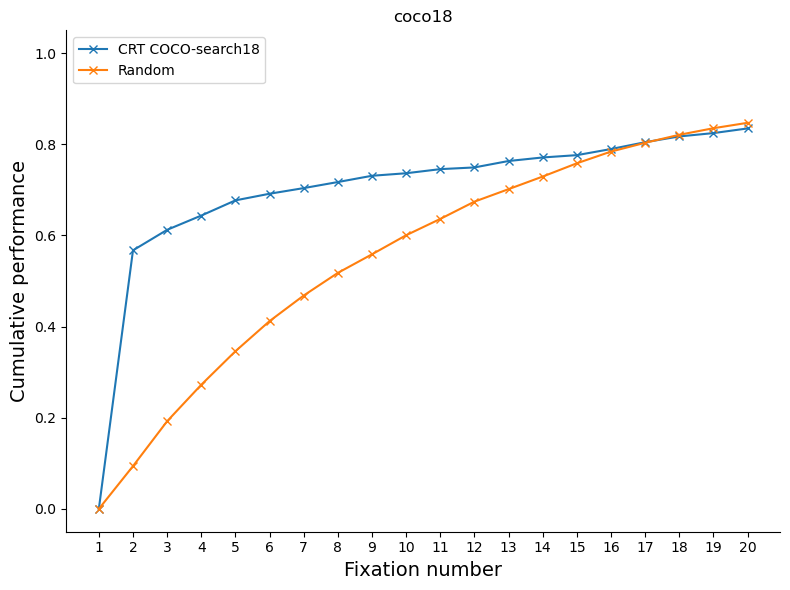

In [23]:
plt.figure(figsize=(8, 6), dpi=100)

for mean, label in zip(avg_cdfs, labels):
    plt.plot(np.arange(1, 21), mean, label=label, marker='x')

plt.xticks(range(1, 21))
plt.ylim([-0.05, 1.05])
plt.legend()
plt.xlabel('Fixation number', fontsize=14)
plt.ylabel('Cumulative performance', fontsize=14)
plt.title(dataset)
plt.legend(loc=2)
sns.despine()
plt.tight_layout()

In [24]:
list(crt_attn.keys())[1]

'bottle_000000086135.jpg'

In [25]:
crt_attn['bottle_000000037367.jpg'].shape

torch.Size([1, 7, 7])

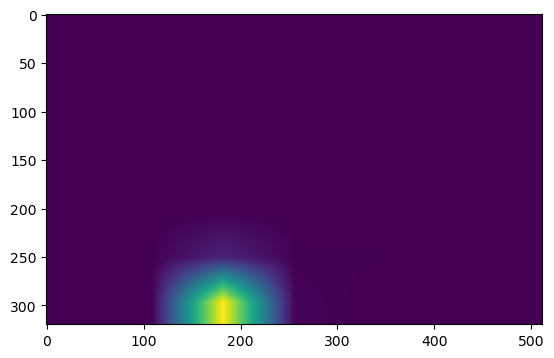

In [26]:
plt.imshow(transforms.Resize((search_h, search_w))(crt_attn['bottle_000000086135.jpg']).detach().cpu().permute(1, 2, 0))

In [27]:
dset.image_info[dset.task]['names'][0]

'000000000939.jpg'

In [102]:
image_idx = 13
task = 'bottle'

In [103]:
dset_config = dict(dataset_dir = dataset_dir, task=task, search_size=(search_h, search_w), target_size=(0, 0), per_target=True, is_transform=True)
dset        = coco18(**dset_config)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


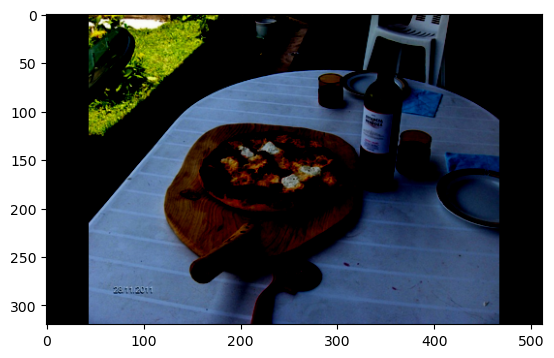

In [104]:
plt.imshow(dset[image_idx][0].permute(1, 2, 0))

In [105]:
dset.image_info[dset.task]['names'][image_idx]

'000000294475.jpg'

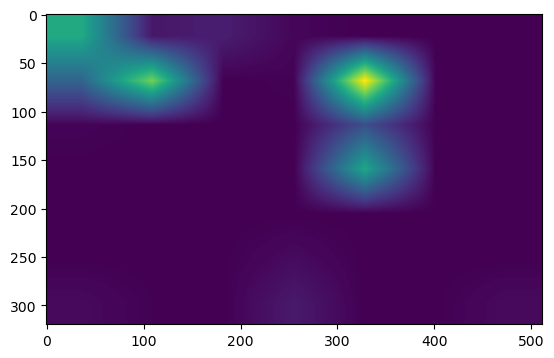

In [106]:
plt.imshow(transforms.Resize((search_h, search_w))(crt_attn[f"{dset.task}_{dset.image_info[dset.task]['names'][image_idx]}"]).detach().cpu().permute(1, 2, 0))

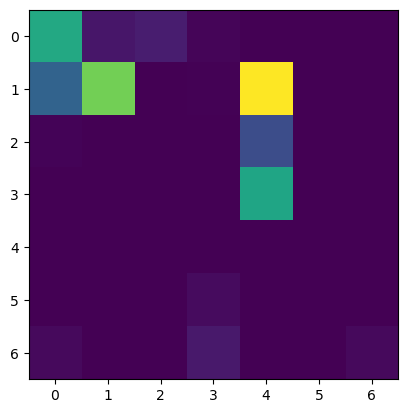

In [107]:
plt.imshow(crt_attn[f"{dset.task}_{dset.image_info[dset.task]['names'][image_idx]}"].detach().cpu().permute(1, 2, 0))